In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv
/kaggle/input/icr-identify-age-related-conditions/greeks.csv
/kaggle/input/icr-identify-age-related-conditions/train.csv
/kaggle/input/icr-identify-age-related-conditions/test.csv


# 1. About this Notebook
The "ICR: Identify Age-Related Conditions" Kaggle competition challenges participants to develop predictive models that can accurately identify age-related conditions in individuals. With access to a provided dataset containing demographic and medical information, participants create machine learning models to predict the presence or likelihood of age-related conditions. 

## Summary
1. The distribution of the target feature is analyzed to assess the imbalance between the values 1 and 0, which helps determine if oversampling is necessary.
2. An analysis of missing values is conducted to check for presence of missing values, which will impact machine learning at later process.
3. Histograms and box plots are employed to visualize the skewness and identify outliers, aiding in the selection of appropriate methods for data standardization.
3. For data processing, the Robust Scaler is chosen to standardize the numerical features, taking into account outlier handling. Additionally, the CatBoost Encoder is utilized for encoding categorical features, and the kNN Imputer is employed for handling missing values.
4. In order to address the class imbalance, the SMOTE (Synthetic Minority Over-sampling Technique) is employed for oversampling the minority class, generating synthetic samples to balance the dataset.
5. Lastly, the XGBoost with hyperparameter tuning is applied.



## Version Control

* Version 1 : Baseline with LGBM
* Version 2 : Add integer denominator for data conversion [does not help to improve the performance]


## 1.1. Library Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
%matplotlib inline
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import uniform, randint

# Suppress any warnings
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn import metrics

# kNN Imputation
from sklearn.impute import KNNImputer, SimpleImputer

# Data Encoder and Scaler
import category_encoders as encoders
from sklearn.preprocessing import LabelEncoder, RobustScaler, QuantileTransformer

# SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE



/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 1.2. Load the Data

In [3]:
# Read the train, test and greeks data

df_train = pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/train.csv")
df_test = pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/test.csv")
df_greeks = pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/greeks.csv")

print('No. of records for train : {}'.format(df_train.shape))
print('No. of records for test : {}'.format(df_test.shape))
print('No. of records for greeks : {}'.format(df_greeks.shape))

No. of records for train : (617, 58)
No. of records for test : (5, 57)
No. of records for greeks : (617, 6)


# 2. EDA

## 2.1. Distribution of Target Label
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
To check if the distribution of target feature (i.e. Class) is balanced.  If it is not the case, we will do oversampling of SMOTE (Synthetic Minority Over-sampling Technique) algorithm in the modelling process.  
</div>

Text(0.5, 1.0, 'Distribution of Target Label (i.e. Class)')

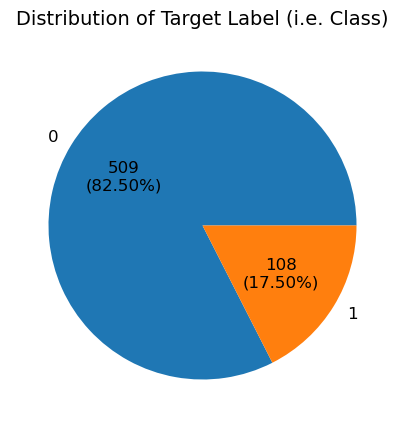

In [4]:
# check whether the data set is balanced

plt.figure(figsize=(5,5))

def auto_fmt (pct_value):
    return '{:.0f}\n({:.2f}%)'.format(df_train['Class'].value_counts().sum()*pct_value/100,pct_value) 

df_transported_count = df_train['Class'].value_counts().rename_axis('Class').reset_index(name='Counts')

fig = plt.gcf()
plt.pie(x=df_transported_count['Counts'], labels=df_transported_count['Class'], autopct=auto_fmt, textprops={'fontsize': 12})
plt.title('Distribution of Target Label (i.e. Class)',  fontsize = 14)

<div style=" background-color:#b22222;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Observation: the distribution of target feature between 1 and 0 cases is uneven. It may be necessary to do oversampling, e.g. SMOTE (Synthetic Minority Over-sampling Technique).
</div>


## 2.2. Missing Value Analysis
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">

Missing values in machine learning can have a significant impact on the performance and accuracy of models, and most machine learning algorithms cannot handle missing value.  To address missing values, imputation techniques are often used to estimate or fill in the missing data.
</div>

In [5]:
# Only include numerical features
df_train_numerical = df_train.drop(['Id', 'EJ', 'Class'], axis=1)

<Figure size 1000x600 with 0 Axes>

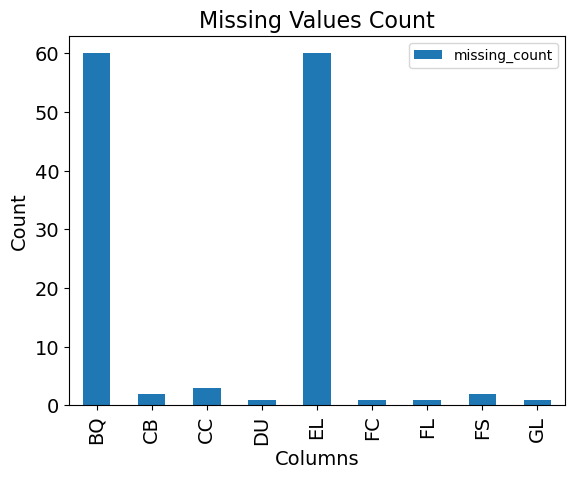

In [6]:

plt.figure(figsize=(10, 6))

# No. of missing values by features
df_train_missing = df_train_numerical.isna().sum()

# Resetting the index
df_train_missing = df_train_missing.reset_index()

# Renaming the columns
df_train_missing.columns = ['feature', 'missing_count']

# Filtering features with missing values
df_train_missing = df_train_missing.loc[df_train_missing['missing_count'] > 0]

# Create a bar chart
df_train_missing.plot.bar(x='feature', y='missing_count')

# Set the chart title and axis labels
plt.title('Missing Values Count', fontsize=16)
plt.xlabel('Columns', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.tick_params(axis='x', which='major', labelsize=14)
plt.tick_params(axis='y', which='major', labelsize=14)

# Display the chart
plt.show()



<div style=" background-color:#b22222;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Observations: The features BQ and EL exhibit a high number of missing values, while some other features also have a few missing values. In order to tackle this issue, we will perform imputation to handle the missing values.
</div>


## 2.3. Descritpive Analysis
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">

Descriptive analysis refers to the process of summarizing and interpreting data to gain insights and understand its main characteristics. It involves the use of various statistical measures and visualization techniques to describe and present data in a meaningful way.
</div>

In [7]:
# Exclude the target label Class and categorical feature EJ in the Describe analysis
# Since there are too many colums for Describe analysis, we need to transpose the results. 

df_train_numerical.describe(include='all').transpose()

,count,mean,std,min,25%,50%,75%,max
AB,617.0,0.477149,0.468388,0.081187,0.252107,0.354659,0.559763,6.161666
AF,617.0,3502.013221,2300.322717,192.593280,2197.345480,3120.318960,4361.637390,28688.187660
AH,617.0,118.624513,127.838950,85.200147,85.200147,85.200147,113.739540,1910.123198
AM,617.0,38.968552,69.728226,3.177522,12.270314,20.533110,39.139886,630.518230
AR,617.0,10.128242,10.518877,8.138688,8.138688,8.138688,8.138688,178.943634
AX,617.0,5.545576,2.551696,0.699861,4.128294,5.031912,6.431634,38.270880
AY,617.0,0.060320,0.416817,0.025578,0.025578,0.025578,0.036845,10.315851
AZ,617.0,10.566447,4.350645,3.396778,8.129580,10.461320,12.969516,38.971568
BC,617.0,8.053012,65.166943,1.229900,1.229900,1.229900,5.081244,1463.693448
BD,617.0,5350.388655,3021.326641,1693.624320,4155.702870,4997.960730,6035.885700,53060.599240


## 2.4. Histogram Analysis for Skewness
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
It examines the shape of the distribution displayed in a histogram to determine the skewness of the data.
</div>

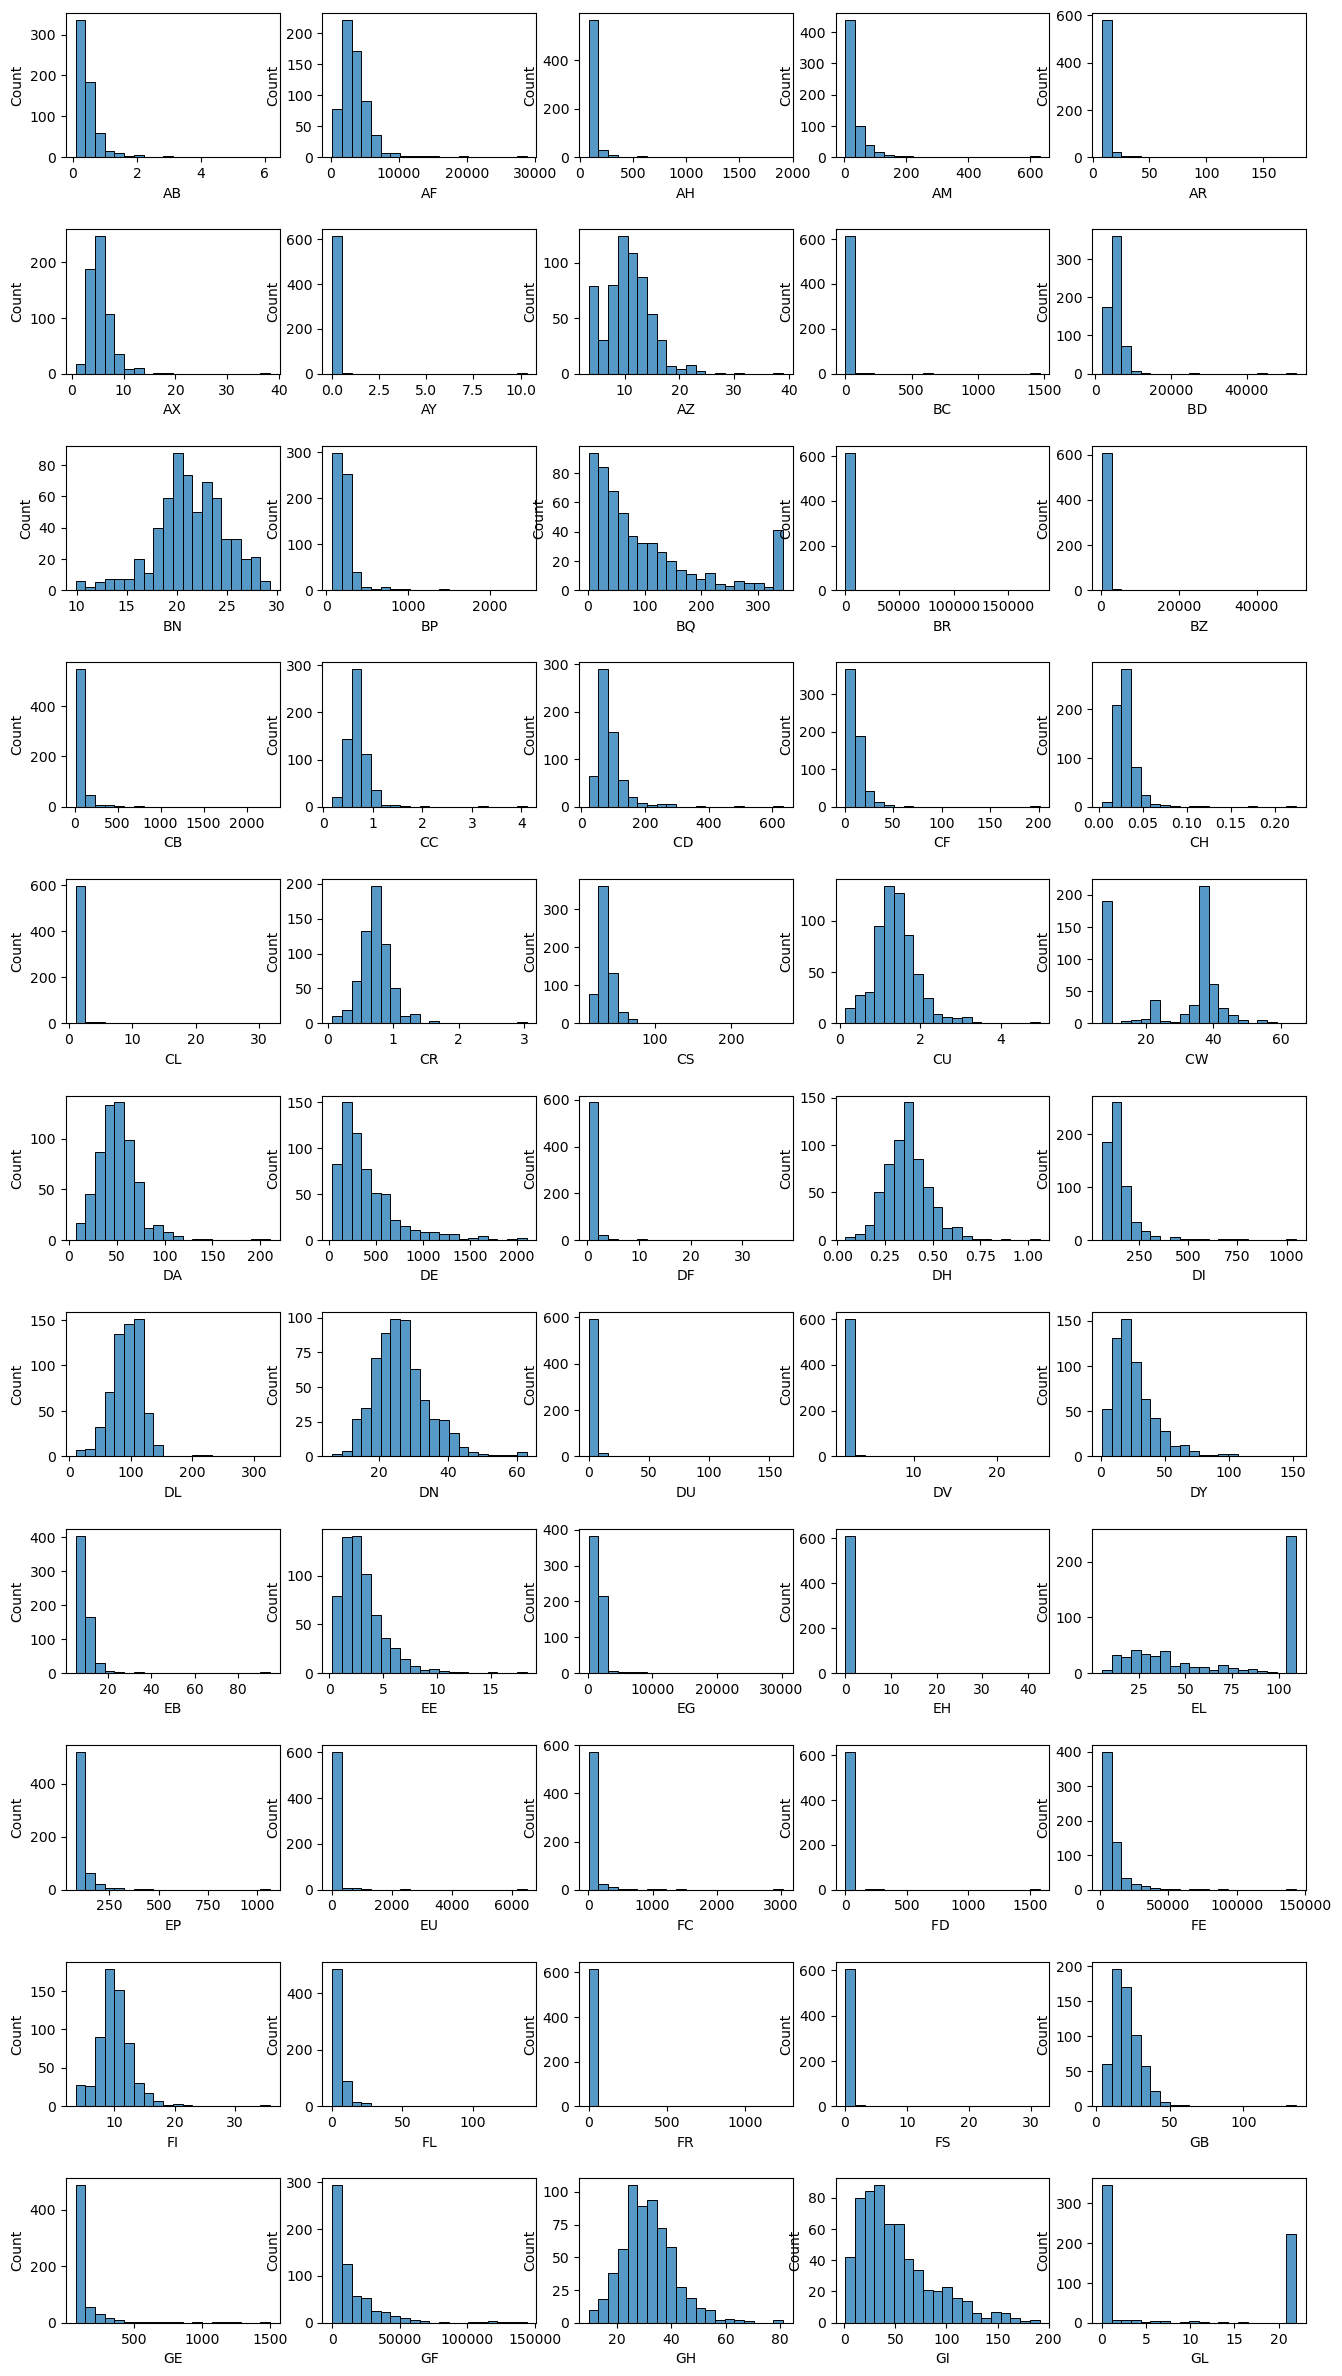

In [8]:
# Histgram for numercial features
fig, ax = plt.subplots(11, 5, figsize=(16,30))

for i in range(0, (len(ax.flatten()))):
#     print('{}, {}'.format(int(i/5),i % 5))
    sns.histplot(data=df_train_numerical, x =df_train_numerical.iloc[:,i], bins=20, ax=ax[int(i/5),i % 5])
#     ax[int(i/5), i % 5].set_title(df_train_numerical.columns[i])

# Adjust the vertical spacing between subplots    
plt.subplots_adjust(hspace=0.5)  

plt.show()

## 2.5. Boxplot Analysis for Outliers
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
It identifies and analyzes outliers in a dataset. A boxplot is a graphical representation that displays the distribution of data and provides insights into the presence of outliers. Here's how you can perform boxplot analysis for outliers
</div>

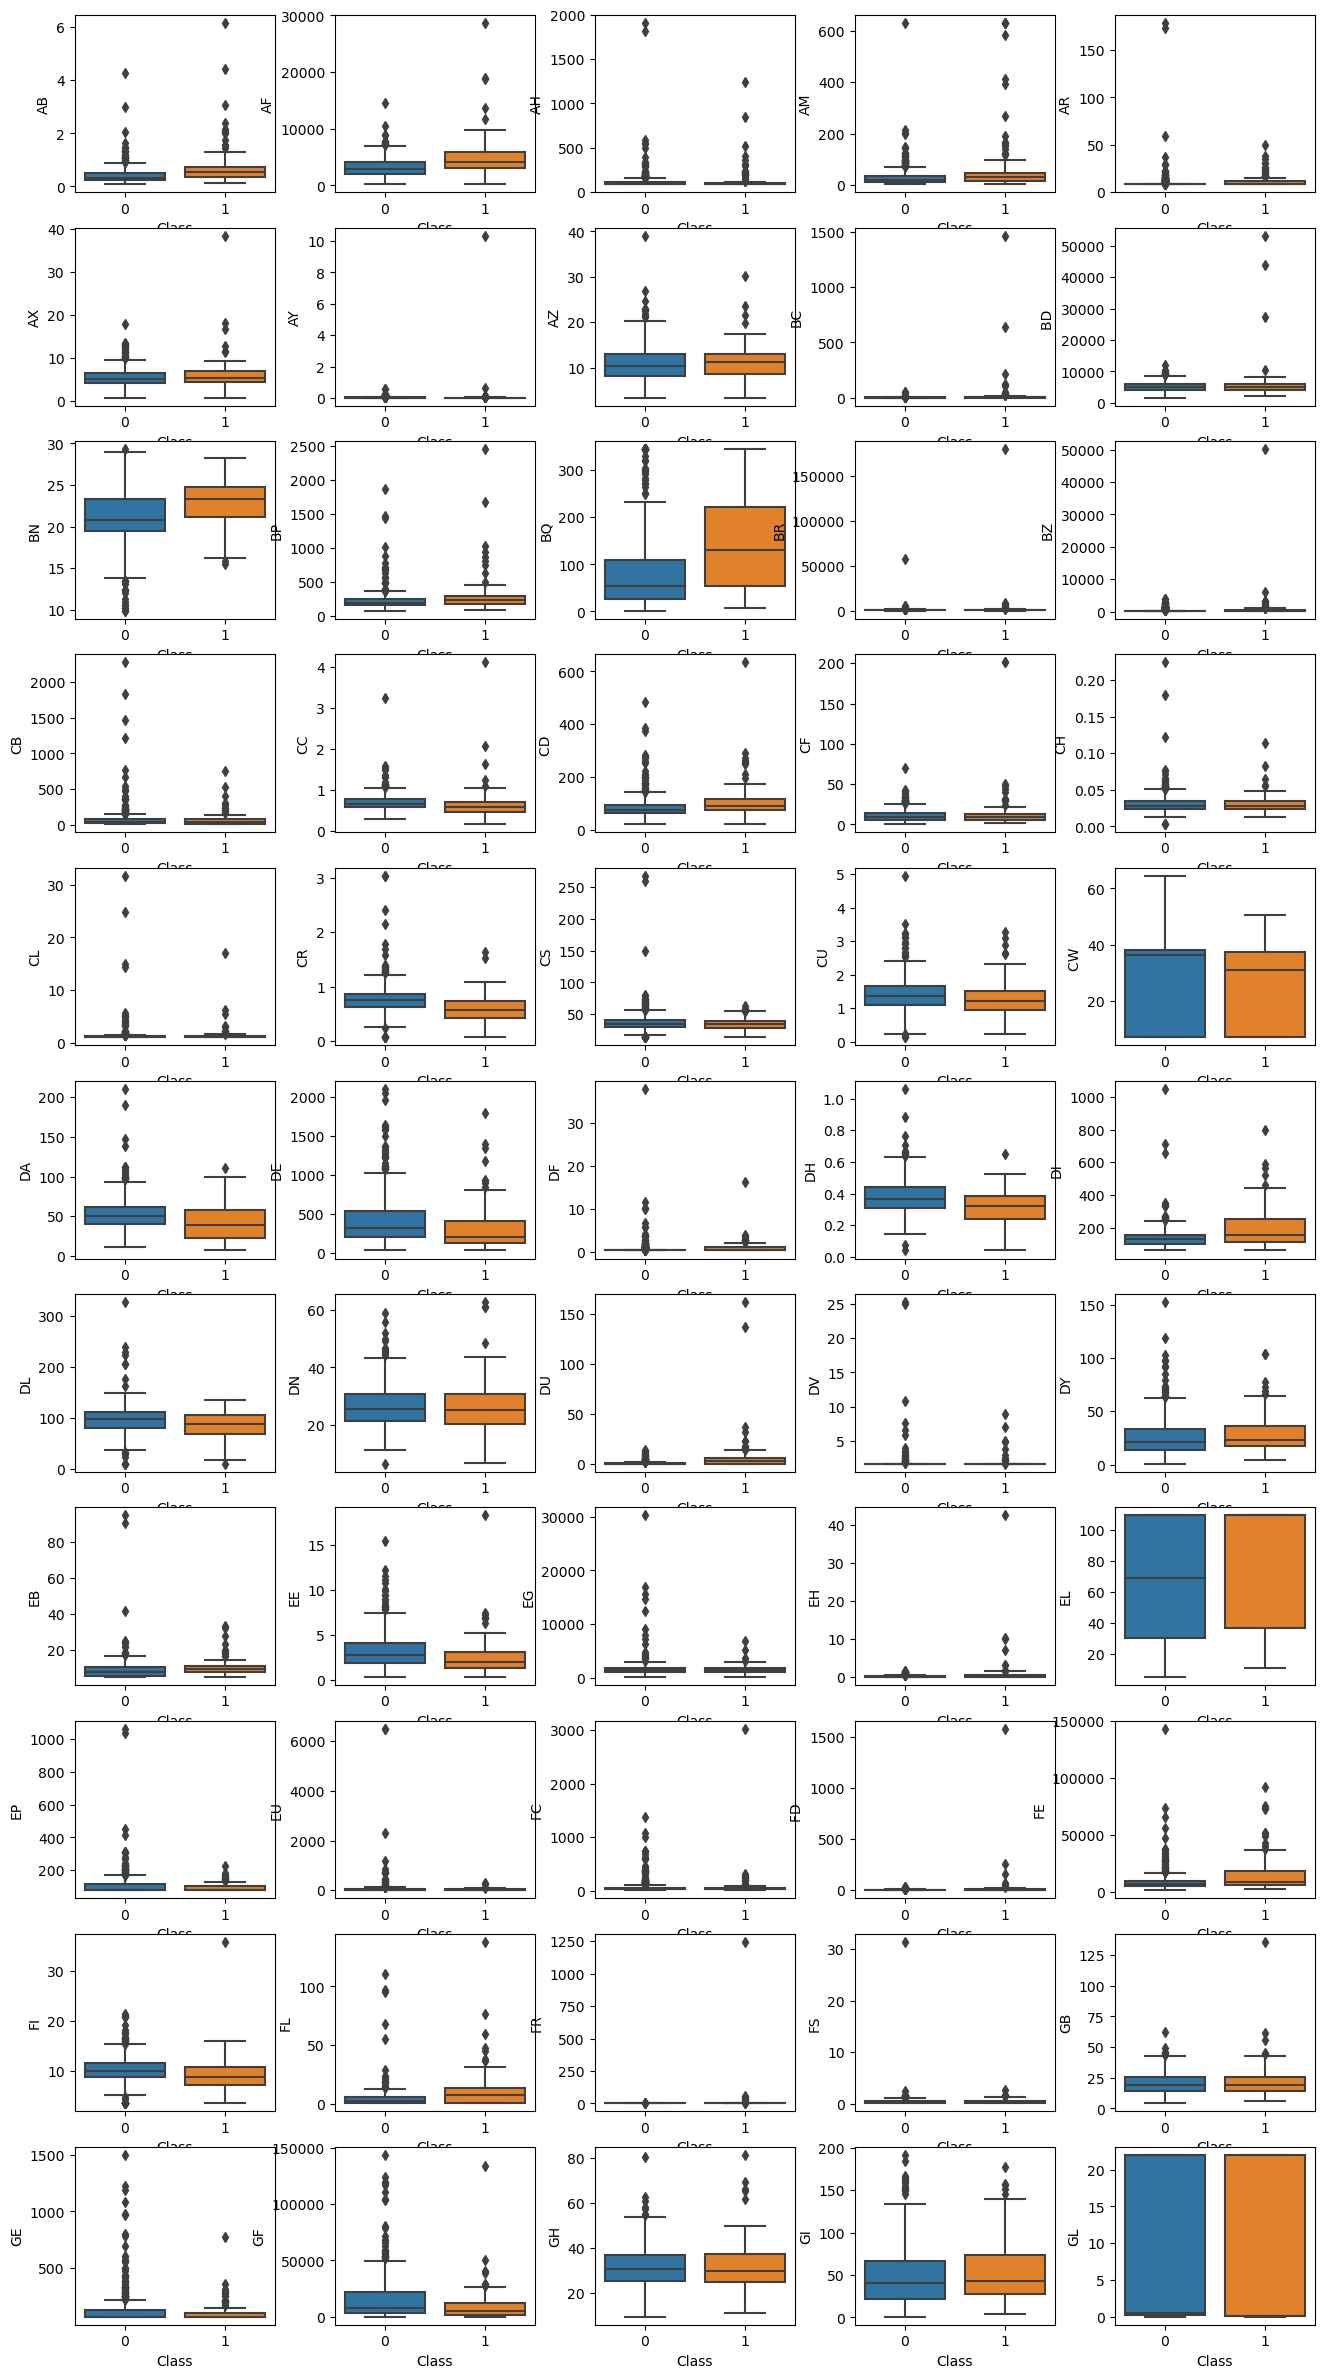

In [9]:
# Histgram for numercial features
fig, ax = plt.subplots(11, 5, figsize=(16,30))

for i in range(0, (len(ax.flatten()))):
    sns.boxplot(x="Class",y=df_train_numerical.columns[i],data=df_train, ax=ax[int(i/5),i % 5])

# Adjust the vertical spacing between subplots    
plt.subplots_adjust(wspace=0.3)  

plt.show()

<div style=" background-color:#b22222;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Observations: based on the descriptive and histogram analysis, it is evident that the numerical features display different variances and distributions. To ensure consistency and comparability, it is crucial to standardize the features by rescaling them before proceeding with the modeling process.
<br><br>
Furthermore, the box plot analysis reveals the presence of outliers in several numerical features. To address the skewness and outliers effectively, we propose utilizing the Robust Scaler for standardizing the numerical features. 
<br><br>    
The Robust Scaler is well-suited for this task as it can automatically handle outliers during the scaling process, providing robustness to extreme values. By employing the Robust Scaler, we can mitigate the impact of outliers and achieve a more reliable and accurate modeling outcome.
</div>


## 2.6. Count Plot for Distribution of Categorical Features
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
This plot is a type of visualization that displays the distribution of categorical features in a dataset. It represents the frequency or count of each category or class within a categorical variable.
</div>

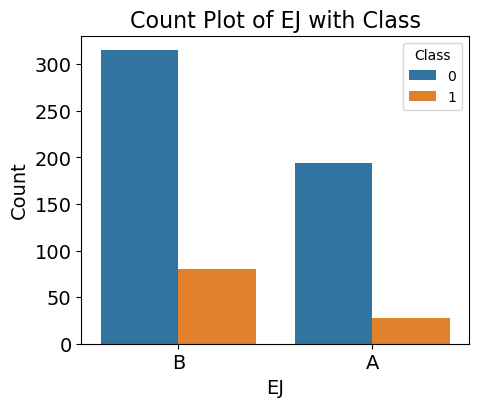

In [10]:
# Set the size of the chart
plt.figure(figsize=(5, 4))
plt.legend(fontsize=13)

# Create the count plot
sns.countplot(data=df_train, x='EJ', hue='Class')

# Set the labels and title
plt.xlabel('EJ', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Count Plot of EJ with Class', fontsize=16)

# Adjust the tick label size
plt.tick_params(axis='x', which='major', labelsize=14)
plt.tick_params(axis='y', which='major', labelsize=14)

# Add a legend
plt.legend(title='Class')

plt.show()

# 3. Data Pre-processing for Model Data

## 3.1. Missing Value Imputation - kNN Imputer
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
Missing value imputation using kNN (k-nearest neighbors) imputer is a technique that fills in missing values in a dataset by estimating them based on the values of their k nearest neighbors. It leverages the similarities between samples to impute missing values, making it a useful method for handling incomplete data.
</div>


In [11]:
# Initialize the KNNImputer with the desired number of neighbors
# Try out the Simple Imputer for performance comparison
imputer = SimpleImputer(strategy='median')

# Perform KNN imputation
df_train_imputed = pd.DataFrame(imputer.fit_transform(df_train[df_train_numerical.columns]), columns=df_train_numerical.columns)
df_test_imputed =pd.DataFrame(imputer.transform(df_test[df_train_numerical.columns]), columns=df_train_numerical.columns)


In [12]:
# Check if there are still missing values in the train and test data sets
df_train_null = df_train_imputed[df_train_imputed.isnull().any(axis=1)]
df_test_null = df_test_imputed[df_test_imputed.isnull().any(axis=1)]

# Display the rows with null values
print('No. of records with missing value in Train data set: {}'.format(df_train_null.shape[0]))
print('No. of records with missing value in Test data set: {}'.format(df_test_null.shape[0]))

# Check the shape of the train and test data set 
print('=' * 50)
print('Shape of the Train data set : {}'.format(df_train_imputed.shape))
print('Shape of the Test data set : {}'.format(df_test_imputed.shape))

No. of records with missing value in Train data set: 0
No. of records with missing value in Test data set: 0
Shape of the Train data set : (617, 55)
Shape of the Test data set : (5, 55)


In [13]:
# Replace the imputed columns in the train data sets
df_train_2 = df_train.drop(df_train_numerical.columns, axis=1)
df_train_2 = pd.concat ([df_train_2, df_train_imputed], axis=1)

# Replace the imputed columns in the test data sets
df_test_2 = df_test.drop(df_train_numerical.columns, axis=1)
df_test_2 = pd.concat ([df_test_2, df_test_imputed], axis=1)

# Check the shape of the train and test data set 
print('Shape of the Train data set : {}'.format(df_train_2.shape))
print('Shape of the Test data set : {}'.format(df_test_2.shape))


Shape of the Train data set : (617, 58)
Shape of the Test data set : (5, 57)


## 3.2. Data Standarization for Numercial Features
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
The RobustScaler is a data preprocessing technique available in the scikit-learn library in Python. It is used to scale numerical data in a robust manner, meaning it is less sensitive to the presence of outliers compared to other scaling methods like standardization or min-max scaling.
</div>

In [14]:
# Create a RobustScaler object
# Try out the QuantileTransformer for performance evaluation
scaler = QuantileTransformer()

# Extract the index
index = df_train_2.index

# Fit the scaler to the data and transform it
scaler_train = scaler.fit_transform(df_train_2[df_train_numerical.columns])
scaler_df_train = pd.DataFrame(scaler_train, columns=df_train_numerical.columns)

# Reassign the index to the scaled DataFrame
scaler_df_train.index = index
print('Shape of Scaled Train Data Set: {}'.format(scaler_df_train.shape))


# Extract the index
index = df_test_2.index

scaler_test = scaler.transform(df_test_2[df_train_numerical.columns])
scaler_df_test = pd.DataFrame(scaler_test, columns=df_train_numerical.columns)

# Reassign the index to the scaled DataFrame
scaler_df_test.index = index
print('Shape of Scaled Test Data Set: {}'.format(scaler_df_test.shape))


Shape of Scaled Train Data Set: (617, 55)
Shape of Scaled Test Data Set: (5, 55)


In [15]:
# Replace the scaled columns in the train data sets
df_train_2 = df_train_2.drop(df_train_numerical.columns, axis=1)
df_train_2 = pd.concat ([df_train_2, scaler_df_train], axis=1)

# Replace the imputed columns in the test data sets
df_test_2 = df_test_2.drop(df_train_numerical.columns, axis=1)
df_test_2 = pd.concat ([df_test_2, scaler_df_test], axis=1)

# Check the shape of the train and test data set 
print('Shape of the Train data set : {}'.format(df_train_2.shape))
print('Shape of the Test data set : {}'.format(df_test_2.shape))


Shape of the Train data set : (617, 58)
Shape of the Test data set : (5, 57)


## 3.3. Data Encoding for Categorical Features
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
CATBoostEncode, or CatBoostEncoder, is a categorical encoding technique specifically designed for the CatBoost algorithm. CatBoost is a gradient boosting algorithm that is known for its strong performance in handling categorical features. The CatBoostEncoder is a specialized encoding method that is compatible with the CatBoost algorithm and aims to effectively encode categorical variables for improved model performance.
</div>

In [16]:
# Load the CatBoost Encoder 
# Try to use simple label encoding method to replace A with 1 and B with 2
# CATBoostENCODE = encoders.CatBoostEncoder()

categorical_cols = ['EJ']

# Define the mapping dictionary for replacement
mapping = {'A': 1, 'B': 2}

print(df_train[categorical_cols].value_counts())

df_train_cat = df_train[categorical_cols].copy()
df_test_cat = df_test[categorical_cols].copy()

# Use apply() with a lambda function to replace values
df_train_cat[categorical_cols] = df_train_cat[categorical_cols].replace(mapping)
df_test_cat[categorical_cols] = df_test[categorical_cols].replace(mapping)

print('After the label encoding')

print(df_train_cat[categorical_cols].value_counts())

# Use CatBoost to encode the categorical values
# encoder_train = CATBoostENCODE.fit_transform(df_train[categorical_cols], df_train['Class'])
# encoded_df_train = pd.DataFrame(encoder_train)
# print('Shape of the Encoded Train Data Set: {}'.format(encoded_df_train.shape))

# encoder_test = CATBoostENCODE.transform(df_test[categorical_cols])
# encoded_df_test = pd.DataFrame(encoder_test)
# print('Shape of the Encoded Test Data Set: {}'.format(encoded_df_test.shape))

EJ
B     395
A     222
dtype: int64
After the label encoding
EJ
2     395
1     222
dtype: int64


In [17]:
# Replace the encoded columns in the train data sets
df_train_2 = df_train_2.drop(categorical_cols, axis=1)
df_train_2 = pd.concat ([df_train_2, df_train_cat], axis=1)

# Replace the imputed columns in the test data sets
df_test_2 = df_test_2.drop(categorical_cols, axis=1)
df_test_2 = pd.concat ([df_test_2, df_test_cat], axis=1)

# Check the shape of the train and test data set 
print('Shape of the Train data set : {}'.format(df_train_2.shape))
print('Shape of the Test data set : {}'.format(df_test_2.shape))

Shape of the Train data set : (617, 58)
Shape of the Test data set : (5, 57)


## 3.4. Oversampling with SMOTE (Synthetic Minority Over-sampling Technique)
<div style=" background-color:#4b371c;text-align:left; padding: 13px 13px; border-radius: 8px; color: white; font-size: 16px">
SMOTE (Synthetic Minority Over-sampling Technique) is a technique  to address the problem of imbalanced datasets. Imbalanced datasets occur when the classes in the target variable are not represented equally, resulting in a skewed distribution. This is a common issue in many real-world classification problems, such as fraud detection, rare disease prediction, or anomaly detection.
</div>

In [18]:
# Before we do the oversampling, we will split the data into training and testing data for model training
train = df_train_2.drop(['Id', 'Class'], axis=1)
test = df_train_2['Class']

# Renaming the columns
test.columns = ['Class']

X_train, X_test, y_train, y_test = train_test_split(train, test, test_size=0.3)

print('Shape of train : {}'.format(X_train.shape))
print('Shape of test : {}'.format(X_test.shape))


Shape of train : (431, 56)
Shape of test : (186, 56)


In [19]:
# Load the SMOTE library 
smote = SMOTE(sampling_strategy={0: 500, 1: 500})
# df_train_numerical = df_train.drop(['Id', 'EJ', 'Class'], axis=1)

X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("length of original data is ",len(df_train_2))
print("Proportion of True data in original data is {:.2%}".format(len(y_train[y_train==1])/len(y_train)))
print("Proportion of False data in original data is {:.2%}".format(len(y_train[y_train==0])/len(y_train)))
print("length of oversampled data is ",len(X_smote))
print("Proportion of True data in oversampled data is {:.2%}".format(len(y_smote[y_smote ==1])/len(y_smote)))
print("Proportion of False data in oversampled data is {:.2%}".format(len(y_smote[y_smote ==0])/len(y_smote)))
   


length of original data is  617
Proportion of True data in original data is 17.17%
Proportion of False data in original data is 82.83%
length of oversampled data is  1000
Proportion of True data in oversampled data is 50.00%
Proportion of False data in oversampled data is 50.00%


# 4. Modelling

In [20]:
# Parameter setup 
folds = 3
iter = 1000

In [21]:
params = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'n_estimators': [50, 100, 500, 1000],
    'num_leaves': randint(5, 50),
    'max_depth': randint(5, 10)
}

lgbm = LGBMClassifier(random_state=42, learning_rate=0.01, n_estimators = 1000)

In [22]:


skf = StratifiedKFold(n_splits=folds, shuffle = True, random_state = 1001)

lgbm_model = RandomizedSearchCV(lgbm, param_distributions=params, n_iter=iter, scoring='roc_auc', n_jobs=-1, cv=skf.split(X_smote, y_smote), verbose=-1, random_state=1001 )

lgbm_model.fit(X_smote, y_smote)

RandomizedSearchCV(cv=<generator object _BaseKFold.split at 0x7d6d4300cdd0>,
                   estimator=LGBMClassifier(learning_rate=0.01,
                                            n_estimators=1000,
                                            random_state=42),
                   n_iter=1000, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7d6d431da800>,
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7d6d4ae7e7a0>},
                   random_state=1001, scoring='roc_auc', verbose=-1)

In [23]:
print(lgbm_model.best_estimator_)
print(lgbm_model.best_params_)

LGBMClassifier(learning_rate=0.01, max_depth=6, n_estimators=1000, num_leaves=7,
               random_state=42)
{'max_depth': 6, 'num_leaves': 7}


## 4.1. Model Performance

In [24]:
def model_performance (p_test, p_test_prob, Y_test, model_name):
    predicted_test = pd.DataFrame(p_test)
    print('=============================================')
    print('Scoring Metrics for {} (Validation)'.format(model_name))
    print('=============================================')
    print('Balanced Accuracy Score = {:2.3f}'.format(metrics.balanced_accuracy_score(Y_test, predicted_test)))
    print('Accuracy Score = {:2.3f}'.format(metrics.accuracy_score(Y_test, predicted_test)))
    print('Precision Score = {:2.3f}'.format(metrics.precision_score(Y_test, predicted_test)))
    print('F1 Score = {:2.3f}'.format(metrics.f1_score(Y_test, predicted_test, labels=['0','1'])))
    print('Recall Score = {:2.3f}'.format(metrics.recall_score(Y_test, predicted_test, labels=['0','1'])))
    print('ROC AUC Score = {:2.3f}'.format(metrics.roc_auc_score(Y_test, predicted_test, labels=['0','1'])))
    print('Confusion Matrix')
    print('==================')
    print(metrics.confusion_matrix(Y_test, predicted_test))
    print('==================')
    print(metrics.classification_report(Y_test, predicted_test, target_names=['0','1']))
    metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(Y_test, predicted_test)).plot()

    # ROC Curve
    fpr_test, tpr_test, _ = metrics.roc_curve(Y_test, p_test_prob)

    roc_auc_test = metrics.roc_auc_score(Y_test, predicted_test, labels=['0','1'])

    # Precision x Recall Curve
    precision_test, recall_test, thresholds_test = metrics.precision_recall_curve(Y_test, p_test_prob)

    print('======= ROC Curve =======')
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))    
    plt.plot(fpr_test, tpr_test, color='darkorange', label='ROC curve - Validation (area = %0.3f)' % roc_auc_test)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    # plt.xlim([0.0, 1.0])
    # plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    
    plt.show()

In [25]:
pred_test = lgbm_model.predict(X_test)
proba_test = lgbm_model.predict_proba(X_test)[:,1]


Scoring Metrics for LGBM (Validation)
Balanced Accuracy Score = 0.786
Accuracy Score = 0.892
Precision Score = 0.750
F1 Score = 0.677
Recall Score = 0.618
ROC AUC Score = 0.786
Confusion Matrix
[[145   7]
 [ 13  21]]
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       152
           1       0.75      0.62      0.68        34

    accuracy                           0.89       186
   macro avg       0.83      0.79      0.81       186
weighted avg       0.89      0.89      0.89       186

======= ROC Curve =======


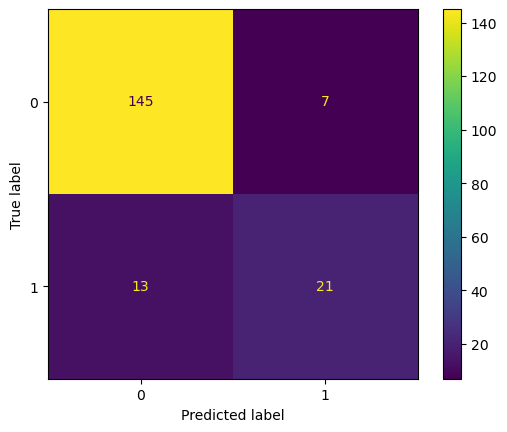

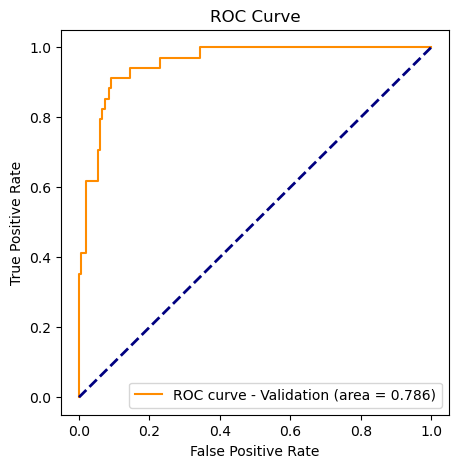

In [26]:
model_performance(pred_test, proba_test, y_test, 'LGBM')

## 4.2. Prediction and Submission

In [27]:
# prediction probability
pred = lgbm_model.predict_proba(df_test_2.drop(['Id'], axis=1))
pred

array([[0.8901003, 0.1098997],
       [0.8901003, 0.1098997],
       [0.8901003, 0.1098997],
       [0.8901003, 0.1098997],
       [0.8901003, 0.1098997]])

In [28]:
submission = df_test_2[['Id']].copy()
submission['Class_0'] = pred[:,0]
submission['Class_1'] = pred[:,1]
submission.to_csv('submission.csv',index=False)
submission.head()

,Id,Class_0,Class_1
0,00eed32682bb,0.8901,0.1099
1,010ebe33f668,0.8901,0.1099
2,02fa521e1838,0.8901,0.1099
3,040e15f562a2,0.8901,0.1099
4,046e85c7cc7f,0.8901,0.1099


### If you find this notebook interesting, please give an upvote as recognition.